# Librerias

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: ignored

In [ ]:
import pandas as pd
pd.set_option("display.max_columns",30)
pd.set_option("display.max_rows",3000)
import matplotlib.pyplot as plt
import cufflinks as cf
cf.go_offline()
import numpy as np

### imputacion variables continuas
from sklearn.impute import SimpleImputer
from scipy.stats import ks_2samp

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Copia de Video_Games_Sales_as_at_22_Dec_2016.csv")

# Analisis Exploratorio

### completitud de informacion

In [ ]:
df.shape

(16719, 16)

In [ ]:
def completitud_datos_nulos(df):
    return df.isnull().sum().sort_values(ascending=False) / df.shape[0]

In [ ]:
df.isnull().sum().sort_values(ascending=False) / df.shape[0]

User_Count         0.546025
Critic_Score       0.513308
Critic_Count       0.513308
Rating             0.404869
User_Score         0.400981
Developer          0.396136
Year_of_Release    0.016089
Publisher          0.003230
Name               0.000120
Genre              0.000120
Platform           0.000000
NA_Sales           0.000000
EU_Sales           0.000000
JP_Sales           0.000000
Other_Sales        0.000000
Global_Sales       0.000000
dtype: float64

### definicion de variables

#### continuas

In [ ]:
varc = [x for x in list(df.describe()) if x not in 'Year_of_Release']

In [ ]:
varc

['NA_Sales',
 'EU_Sales',
 'JP_Sales',
 'Other_Sales',
 'Global_Sales',
 'Critic_Score',
 'Critic_Count',
 'User_Count']

##### Analasis univariado

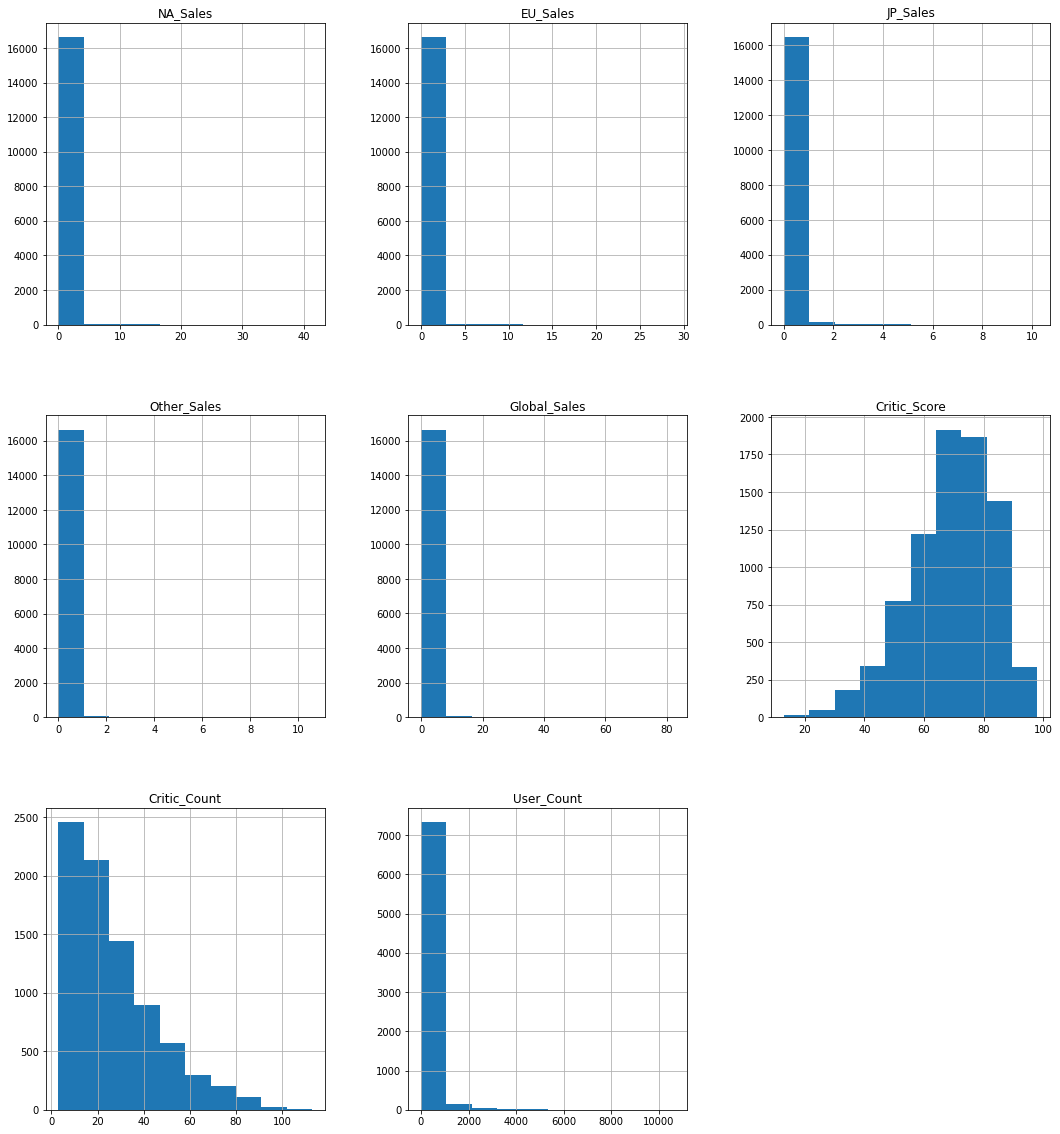

In [ ]:
df[varc].hist(figsize=(18,20));

###  Eliminacion de valores extremos

In [ ]:
percentiles = {}
for var in varc:
    perc1 = df[f"{var}"].describe([x/10 for x in range(10)] + [0.01, 0.05, 0.25, 0.75, 0.95, 0.99]).to_frame().loc['1%',:]
    perc99 = df[f"{var}"].describe([x/10 for x in range(10)] + [0.01, 0.05, 0.25, 0.75, 0.95, 0.99]).to_frame().loc['99%',:]
    minimo = df[f"{var}"].describe([x/10 for x in range(10)] + [0.01, 0.05, 0.25, 0.75, 0.95, 0.99]).to_frame().loc['min',:]
    maximo = df[f"{var}"].describe([x/10 for x in range(10)] + [0.01, 0.05, 0.25, 0.75, 0.95, 0.99]).to_frame().loc['max',:]

    izq = round(perc1[0],3)
    der = round(perc99[0],3)
    print(minimo[0])
    print(izq)
    print(der)
    print(maximo[0])
    outliersPerc = df[f"{var}"][~((df[f"{var}"]<=izq) | (df[f"{var}"]>=der))].to_frame()
    percentiles[f"{var}"] = (outliersPerc[var].shape[0])
    df[f"{var}"] = outliersPerc[var]

0.0
0.0
2.79
41.36
0.0
0.0
1.938
28.96
0.0
0.0
1.268
10.22
0.0
0.0
0.63
10.57
0.01
0.01
5.458
82.53
13.0
31.0
94.0
98.0
3.0
4.0
84.0
113.0
4.0
4.0
2527.33
10665.0


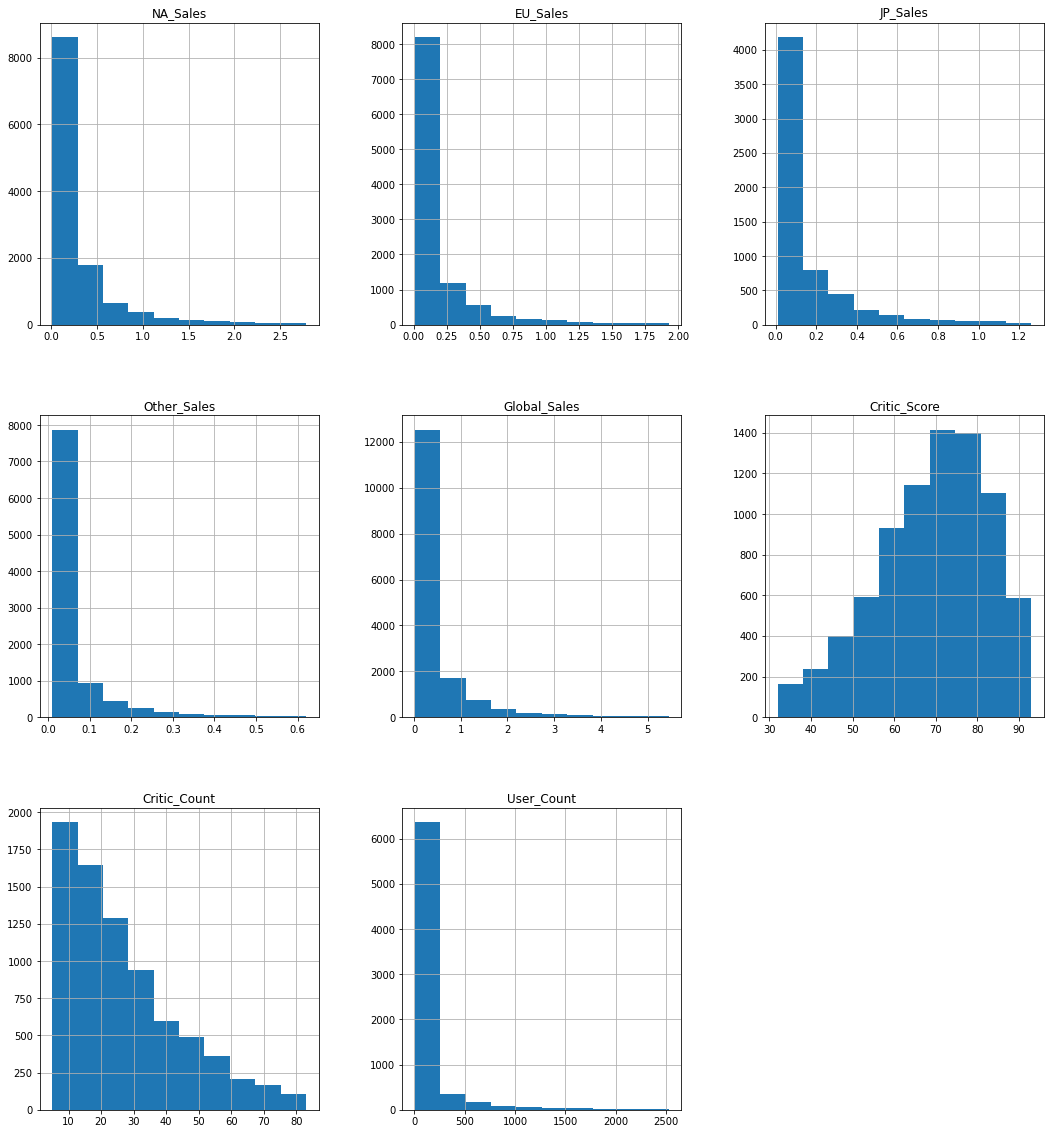

In [ ]:
df[varc].hist(figsize=(18,20));

In [ ]:
df.shape

(16719, 16)

#### categoricas

In [ ]:
vard = [y for y in df.columns if y not in varc]

In [ ]:
vard

['Name',
 'Platform',
 'Year_of_Release',
 'Genre',
 'Publisher',
 'User_Score',
 'Developer',
 'Rating']

In [ ]:
for x in df[vard]:
    print(x)
    df.sample(frac=0.01)[x].iplot(kind="bar",theme="white")

In [ ]:
var_year = ["Year_of_Release"]
df[var_year].min(), df[var_year].max()

(Year_of_Release    1980.0
 dtype: float64, Year_of_Release    2020.0
 dtype: float64)

# Tratamiento o Ingeniera de los datos

In [ ]:
df["Year_of_Release"] = df["Year_of_Release"].map(lambda x: str(x).split(".")[0])

In [ ]:
completitud_datos_nulos(df[varc])

In [ ]:
len(df["User_Count"].value_counts(True)*100)

814

In [ ]:
df["User_Count"].value_counts(True)*100

In [ ]:
df[df["User_Count"].isnull()]

#### Imputacion datos continuos

In [ ]:
X = df[["User_Count","Critic_Score","Critic_Count"]].copy()
im = SimpleImputer(strategy="median")

In [ ]:
X.shape
im.fit_transform(X).shape

(1581, 8)

In [ ]:
Xi = pd.DataFrame(im.fit_transform(X), columns=["User_Count","Critic_Score","Critic_Count"])
l_ks = []

In [ ]:
for v in ["User_Count","Critic_Score","Critic_Count"]:
    l_ks.append([v,ks_2samp(X[v].dropna(),Xi[v]).statistic])
ks = pd.DataFrame(l_ks, columns=["feat","ks"])
print((ks.ks>=0.1).sum())
df[["User_Count","Critic_Score","Critic_Count"]] = im.transform(df[["User_Count","Critic_Score","Critic_Count"]].copy())

3


In [ ]:
def complete_continuous_variables(df,col,strategy='median'):
    X = df[col].copy()
    im = SimpleImputer(strategy=strategy)
    Xi = pd.DataFrame(im.fit_transform(X),columns=col)
    l_ks = []
    for v in col:
        l_ks.append([v,ks_2samp(X[v].dropna(),Xi[v]).statistic])
    ks = pd.DataFrame(l_ks,columns=['feat','ks'])
    #print(ks)
    print((ks.ks>=0.1).sum())
    df[col] = im.transform(df[col].copy())
    return df

In [ ]:
varc

['NA_Sales',
 'EU_Sales',
 'JP_Sales',
 'Other_Sales',
 'Global_Sales',
 'Critic_Score',
 'Critic_Count',
 'User_Count']

In [ ]:
df

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,NaN,NaN,NaN,NaN,NaN,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985,Platform,Nintendo,NaN,NaN,NaN,NaN,NaN,71.0,22.0,NaN,26.0,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,NaN,NaN,NaN,NaN,NaN,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,NaN,NaN,NaN,NaN,NaN,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,NaN,NaN,NaN,NaN,NaN,71.0,22.0,NaN,26.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016,Action,Tecmo Koei,NaN,NaN,0.01,NaN,NaN,71.0,22.0,NaN,26.0,NaN,NaN
16715,LMA Manager 2007,X360,2006,Sports,Codemasters,NaN,0.01,NaN,NaN,NaN,71.0,22.0,NaN,26.0,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016,Adventure,Idea Factory,NaN,NaN,0.01,NaN,NaN,71.0,22.0,NaN,26.0,NaN,NaN
16717,Spirits & Spells,GBA,2003,Platform,Wanadoo,0.01,NaN,NaN,NaN,NaN,71.0,22.0,NaN,26.0,NaN,NaN


In [ ]:
df = df.dropna().reset_index(drop=True)

# Modelacion no supervisada

In [ ]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#X = data[best].sample(frac=0.1).reset_index(drop=True).copy()
X = df[varc].reset_index(drop=True).copy()
X_perfil = X

In [ ]:
scaler = StandardScaler()
scaler.fit(X)
Xs = pd.DataFrame(scaler.transform(X), columns=X.columns)
pca = PCA(n_components=3)
mds = MDS(n_components=3, n_jobs=.1)
tsne= TSNE()
pca.fit(Xs)

PCA(n_components=3)

In [ ]:
pca.explained_variance_ratio_.cumsum()

array([0.49399986, 0.64012609, 0.76638144])

In [ ]:
Xp = pd.DataFrame(pca.transform(Xs), columns=["p1","p2","p3"])

# Definicion de CLuster

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

In [ ]:
lst_in = []
for k in range(1,9):
    km = KMeans(n_clusters=k)
    km.fit(Xs)
    lst_in.append(km.inertia_)

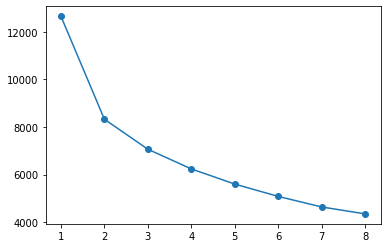

In [ ]:
plt.plot(range(1,9),lst_in,marker='o');

In [ ]:
minmax = MinMaxScaler()

In [ ]:
minmax.fit(X)

In [ ]:
Xmm = pd.DataFrame(minmax.transform(X), columns=X.columns)

In [ ]:
lst = []
for k in range(1,9):
    km = KMeans(n_clusters=k)
    km.fit(Xmm)
    lst.append(km.inertia_)

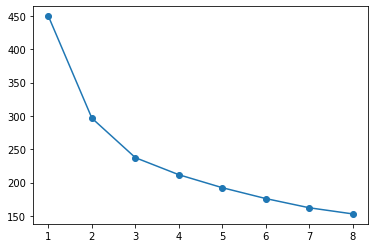

In [ ]:
plt.plot(range(1,9),lst,marker='o');

In [ ]:
cl_xp = GaussianMixture(n_components=3, max_iter=2000)
#cl_xt = GaussianMixture(n_components=3, max_iter=2000)

In [ ]:
cl_xp.fit(Xp)
#cl_xt.fit(Xt)

In [ ]:
Xp["cl"] = cl_xp.predict(Xp)
#Xt["cl"] = cl_xt.predict(Xt)

In [ ]:
import cufflinks as cf
cf.go_offline()
import plotly.express as px
fig = px.scatter_3d(Xp, x='p1', y='p2', z='p3',
              color='cl')
fig.show()

In [ ]:
import cufflinks as cf
cf.go_offline()
import plotly.express as px
fig = px.scatter_3d(Xp, x='p1', y='p2', z='p3',
              color='cl')
fig.show()

In [ ]:
print("PCA")
Xp.cl.value_counts(True)

PCA


2    0.428843
0    0.364959
1    0.206199
Name: cl, dtype: float64

# Perfilamiento

In [ ]:
#len(df_credit), len(Xp), len(X)

In [ ]:
#perfil = pd.concat([X,df_credit[vard], Xp], axis=1)

In [ ]:
#perfil.groupby("cl").mean()

In [ ]:
#perfil.mean().to_frame().T